<a href="https://colab.research.google.com/github/thaiantl-code/hocsau/blob/main/CIFAR_heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Torchvision
import torchvision
import torchvision.transforms as transforms

# DataLoader
from torch.utils.data import DataLoader

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [3]:
# ============================================================
# 2. DEVICE CONFIGURATION
# ============================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Using device:", device)

Using device: cuda


In [5]:
# ============================================================
# 2. IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize image
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Định nghĩa các phép biến đổi (Transform)
# Chuyển ảnh PIL sang Tensor và chuẩn hóa pixel về khoảng [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Tải tập Training
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

# 3. Tải tập Testing
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

# Khai báo tên các lớp của CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [09:10<00:00, 310kB/s] 


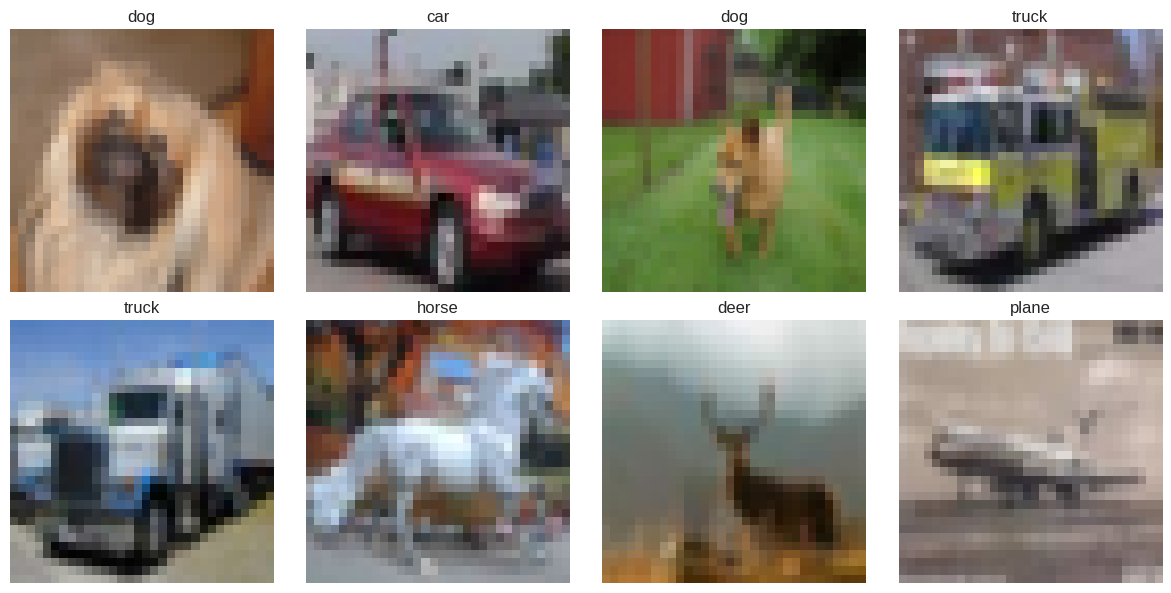

In [7]:
# ============================================================
# 4.VISUALIZE SAMPLE IMAGES
# ============================================================

images, labels = next(iter(trainloader))

plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i] / 2 + 0.5

    img = img.permute(1,2,0)

    plt.imshow(img)

    plt.title(classes[labels[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 5.CNN MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        # ----------------------------------------------------
        # CONVOLUTION BLOCK 1
        # ----------------------------------------------------

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # ----------------------------------------------------
        # CONVOLUTION BLOCK 2
        # ----------------------------------------------------

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # ----------------------------------------------------
        # CONVOLUTION BLOCK 3
        # ----------------------------------------------------

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # ----------------------------------------------------
        # ACTIVATION & POOLING
        # ----------------------------------------------------

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # ----------------------------------------------------
        # FULLY CONNECTED LAYERS
        # ----------------------------------------------------

        self.fc1 = nn.Linear(
            128 * 4 * 4,
            256
        )

        self.fc2 = nn.Linear(
            256,
            10
        )

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):

        # Conv Block 1
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        # Conv Block 2
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        # Conv Block 3
        x = self.relu(self.conv3(x))
        x = self.pool(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [9]:
# ============================================================
# 6. INITIALIZE MODEL
# ============================================================

model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [10]:
# ============================================================
# 7. LOSS FUNCTION & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [11]:
# ============================================================
# TRAINING LOOP
# ============================================================

epochs = 15

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    # --------------------------------------------------------
    # TRAIN MODE
    # --------------------------------------------------------

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total

    train_losses.append(running_loss)
    train_accuracies.append(train_accuracy)

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    test_accuracy = correct / total

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Acc: {train_accuracy:.4f} "
        f"Test Acc: {test_accuracy:.4f}"
    )

Epoch [1/15] Train Acc: 0.4702 Test Acc: 0.5949
Epoch [2/15] Train Acc: 0.6218 Test Acc: 0.6774
Epoch [3/15] Train Acc: 0.6886 Test Acc: 0.6981
Epoch [4/15] Train Acc: 0.7252 Test Acc: 0.7374
Epoch [5/15] Train Acc: 0.7560 Test Acc: 0.7337
Epoch [6/15] Train Acc: 0.7807 Test Acc: 0.7472
Epoch [7/15] Train Acc: 0.8001 Test Acc: 0.7582
Epoch [8/15] Train Acc: 0.8172 Test Acc: 0.7514
Epoch [9/15] Train Acc: 0.8301 Test Acc: 0.7593
Epoch [10/15] Train Acc: 0.8461 Test Acc: 0.7636
Epoch [11/15] Train Acc: 0.8591 Test Acc: 0.7517
Epoch [12/15] Train Acc: 0.8673 Test Acc: 0.7598
Epoch [13/15] Train Acc: 0.8764 Test Acc: 0.7631
Epoch [14/15] Train Acc: 0.8832 Test Acc: 0.7556
Epoch [15/15] Train Acc: 0.8880 Test Acc: 0.7630


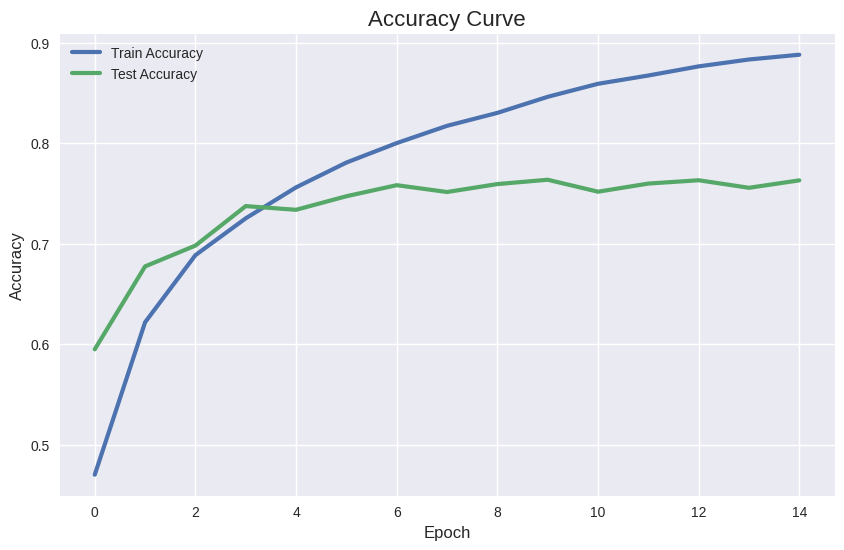

In [13]:
# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_accuracies,
    label='Train Accuracy',
    linewidth=3
)

plt.plot(
    test_accuracies,
    label='Test Accuracy',
    linewidth=3
)

plt.title("Accuracy Curve", fontsize=16)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

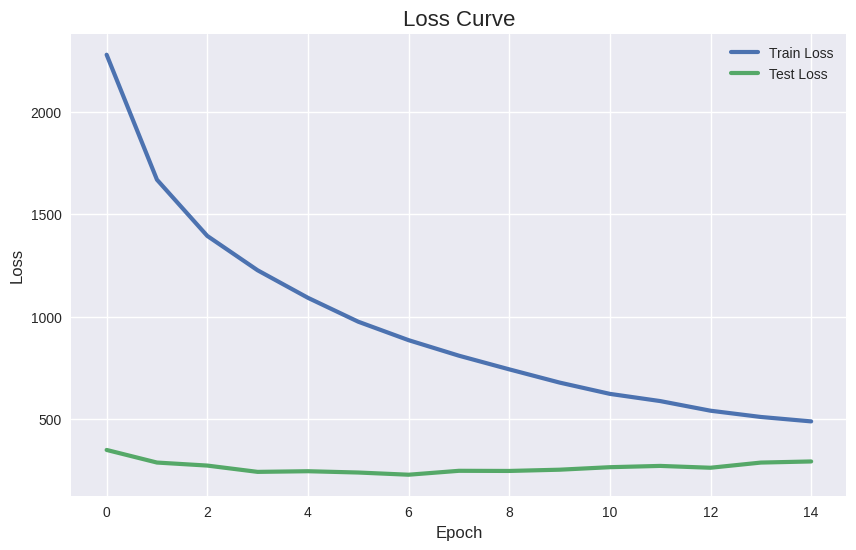

In [14]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    label='Train Loss',
    linewidth=3
)

plt.plot(
    test_losses,
    label='Test Loss',
    linewidth=3
)

plt.title("Loss Curve", fontsize=16)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

In [15]:
# ============================================================
# MODEL EVALUATION
# ============================================================

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [16]:
# ============================================================
# METRICS
# ============================================================

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Precision: 0.7662795743689661
Recall   : 0.763
F1-score : 0.7638945831274354


In [17]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

       plane       0.79      0.81      0.80      1000
         car       0.89      0.86      0.88      1000
        bird       0.64      0.68      0.66      1000
         cat       0.57      0.61      0.59      1000
        deer       0.71      0.74      0.73      1000
         dog       0.71      0.65      0.68      1000
        frog       0.88      0.76      0.81      1000
       horse       0.79      0.81      0.80      1000
        ship       0.85      0.86      0.86      1000
       truck       0.83      0.85      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



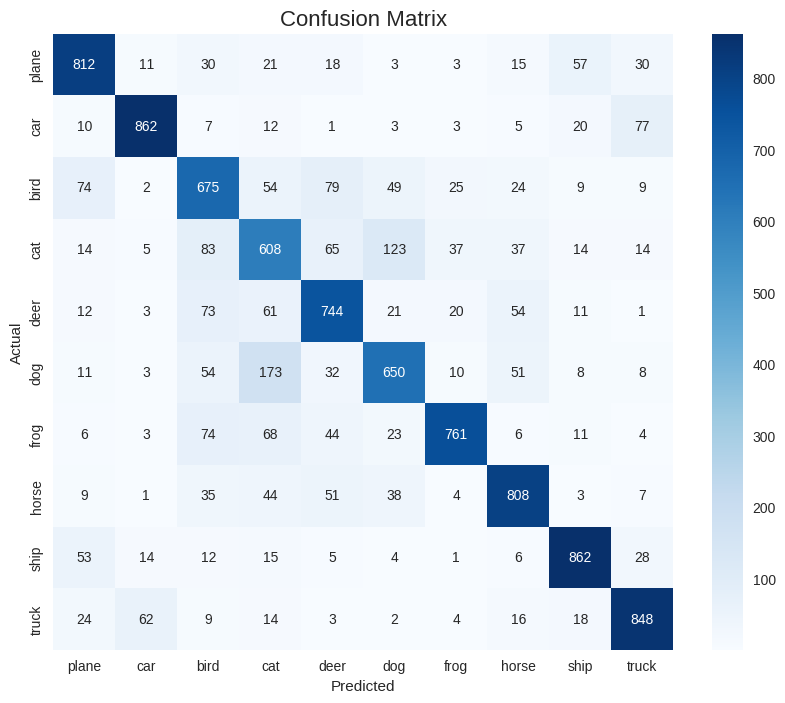

In [18]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix", fontsize=16)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# ============================================================
# FEATURE MAP EXTRACTION
# ============================================================

feature_maps = []

def hook_fn(module, input, output):

    feature_maps.append(output)

# Register hooks
model.conv1.register_forward_hook(hook_fn)
model.conv3.register_forward_hook(hook_fn)

In [24]:
# ============================================================
# FORWARD SINGLE IMAGE
# ============================================================

# ============================================================
# FORWARD SINGLE IMAGE
# ============================================================

# Lấy 1 batch
images, labels = next(iter(testloader))

# Lấy ảnh đầu tiên trong batch
image = images[0]
label = labels[0]

# Thêm batch dimension
input_image = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    _ = model(input_image)

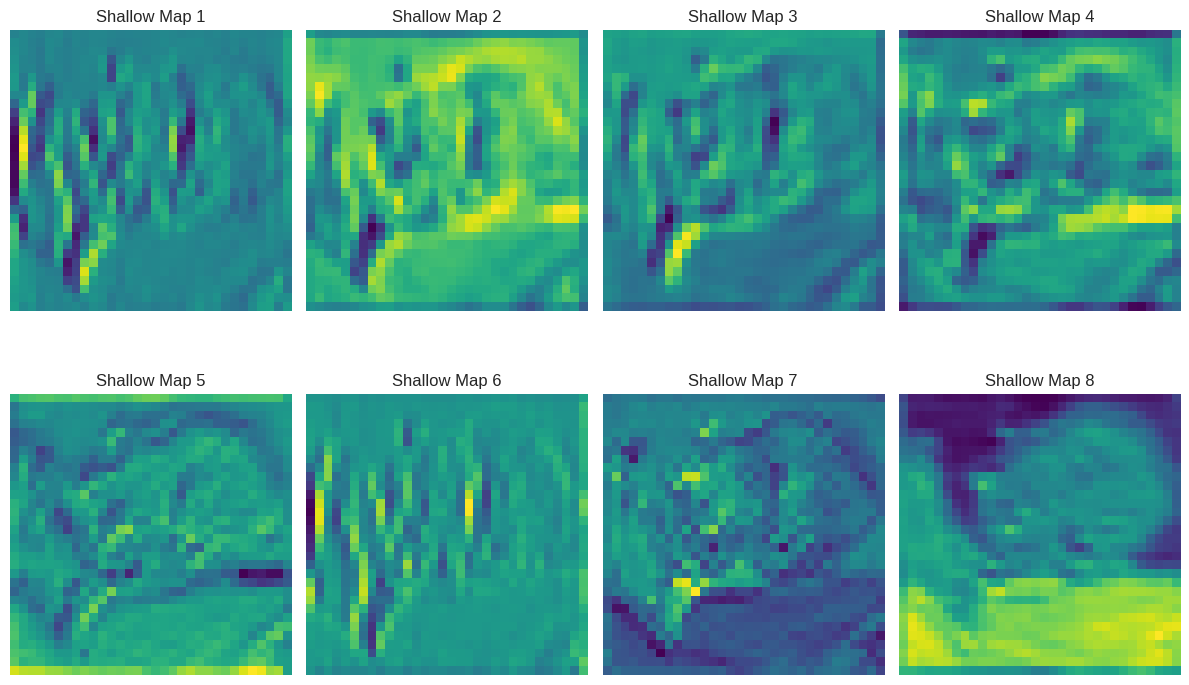

In [25]:
# ============================================================
# SHALLOW FEATURE MAPS
# ============================================================

shallow_maps = feature_maps[0].squeeze(0)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(
        shallow_maps[i].cpu(),
        cmap='viridis'
    )

    plt.title(f'Shallow Map {i+1}')

    plt.axis('off')

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# DEEP FEATURE MAPS
# ============================================================

deep_maps = feature_maps[1].squeeze(0)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(
        deep_maps[i].cpu(),
        cmap='viridis'
    )

    plt.title(f'Deep Map {i+1}')

    plt.axis('off')

plt.tight_layout()

plt.show()